<a href="https://colab.research.google.com/github/vanisreebachhu/Customer-Churn-Prediction/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

print("Customer Churn Prediction Project Started!")

Customer Churn Prediction Project Started!


# Customer Churn Prediction using Machine Learning

This project predicts whether a customer is likely to churn using Machine Learning.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

In [ ]:
data = {
      "Age": [22, 25, 30, 35, 40, 45, 50, 28, 32, 38],
          "MonthlyCharges": [50, 60, 70, 80, 90, 100, 110, 55, 75, 85],
              "Tenure": [2, 5, 10, 1, 8, 12, 15, 3, 7, 9],
                  "Churn": [1, 0, 0, 1, 0, 0, 0, 1, 0, 1]
                  }
df = pd.DataFrame(data)

print(df)


   Age  MonthlyCharges  Tenure  Churn
0   22              50       2      1
1   25              60       5      0
2   30              70      10      0
3   35              80       1      1
4   40              90       8      0
5   45             100      12      0
6   50             110      15      0
7   28              55       3      1
8   32              75       7      0
9   38              85       9      1


In [ ]:
import pandas as pd
import numpy as np

print("Customer Churn Prediction Project Started!")

Customer Churn Prediction Project Started!


## Conclusion

The Customer Churn Prediction model was developed using Logistic Regression.

The model uses customer Age, Monthly Charges, and Tenure to predict whether a customer is likely to churn.

This project demonstrates data cleaning, data analysis, data visualization, machine learning model training, evaluation, and prediction.

In [ ]:
# Display the customer dataset
df.head()

,Age,MonthlyCharges,Tenure,Churn
0,22,50,2,1
1,25,60,5,0
2,30,70,10,0
3,35,80,1,1
4,40,90,8,0


In [ ]:
# Check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Age             10 non-null     int64
 1   MonthlyCharges  10 non-null     int64
 2   Tenure          10 non-null     int64
 3   Churn           10 non-null     int64
dtypes: int64(4)
memory usage: 452.0 bytes


In [ ]:
# Check for missing values
df.isnull().sum()

,0
Age,0
MonthlyCharges,0
Tenure,0
Churn,0


In [ ]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [ ]:
# Check Churn distribution
df["Churn"].value_counts()

,count
Churn,
0,6
1,4


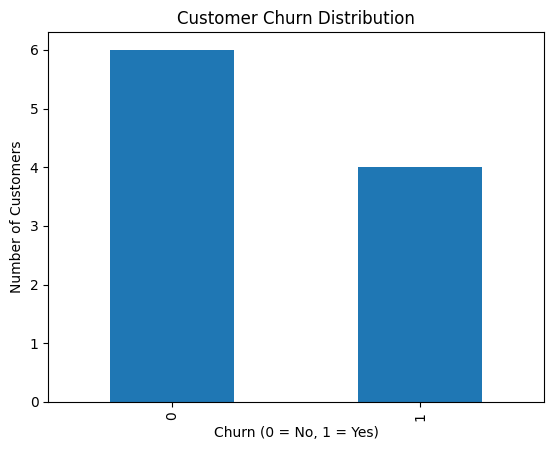

In [ ]:
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:
# Analyze Age and Churn
df.groupby("Churn")["Age"].mean()

,Age
Churn,
0,37.00
1,30.75


In [ ]:
# Analyze Monthly Charges and Churn
# Analyze Tenure andh Churn
# Analyze Tenure and Churn
df.groupby("Churn")["Tenure"].mean()

,Tenure
Churn,
0,9.50
1,3.75


In [ ]:
# Separate features and target

X = df[["Age", "MonthlyCharges", "Tenure"]]
y = df["Churn"]

print("Features:")
print(X)

print("\nTarget:")
print(y)

Features:
   Age  MonthlyCharges  Tenure
0   22              50       2
1   25              60       5
2   30              70      10
3   35              80       1
4   40              90       8
5   45             100      12
6   50             110      15
7   28              55       3
8   32              75       7
9   38              85       9

Target:
0    1
1    0
2    0
3    1
4    0
5    0
6    0
7    1
8    0
9    1
Name: Churn, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    )
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8, 3)
Testing data: (2, 3)


In [ ]:
from sklearn.linear_model import LogisticRegression

# Create the model
model = LogisticRegression()

# Train the model
model.fit(X_train, y_train)

print("Model Training Completed!")

Model Training Completed!


In [ ]:
# Predict churn for test data
y_pred = model.predict(X_test)

print("Actual Churn:")
print(y_test.values)

print("\nPredicted Churn:")
print(y_pred)

Actual Churn:
[0 1]

Predicted Churn:
[0 1]


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Model Accuracy: 1.0
Accuracy Percentage: 100.0 %


In [ ]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix

# Calculate Precision and Recall
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)

print("Precision:", precision)
print("Recall:", recall)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

Precision: 1.0
Recall: 1.0

Confusion Matrix:
[[1 0]
 [0 1]]


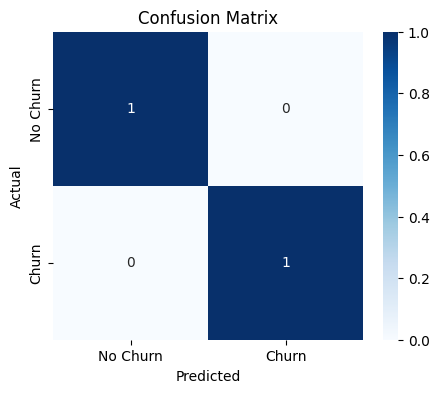

In [ ]:
import seaborn as sns

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
        annot=True,
            fmt="d",
                cmap="Blues",
                    xticklabels=["No Churn", "Churn"],
                        yticklabels=["No Churn", "Churn"]
                        )
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Predict churn for a new customer

new_customer = pd.DataFrame({
    "Age": [29],
        "MonthlyCharges": [65],
            "Tenure": [4]
            })
prediction = model.predict(new_customer)
if prediction[0] == 1:
  print("Prediction: Customer may Churn")
else:
  print("Prediction: Customer may Not Churn")

Prediction: Customer may Churn


In [ ]:
# Check churn probability

probability = model.predict_proba(new_customer)

print("Probability of No Churn:", probability[0][0])
print("Probability of Churn:", probability[0][1])

Probability of No Churn: 0.4039599301960253
Probability of Churn: 0.5960400698039747


In [ ]:
# Analyze Tenure andh Churn
df.groupby("Churn")["Tenure"].mean ()

,Tenure
Churn,
0,9.50
1,3.75


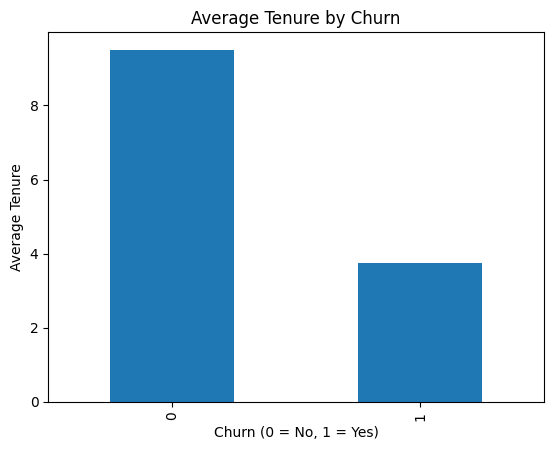

In [ ]:
# Tenure vs Churn visualization
df.groupby("Churn")["Tenure"].mean().plot(kind="bar")

plt.title("Average Tenure by Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Average Tenure")
plt.show()

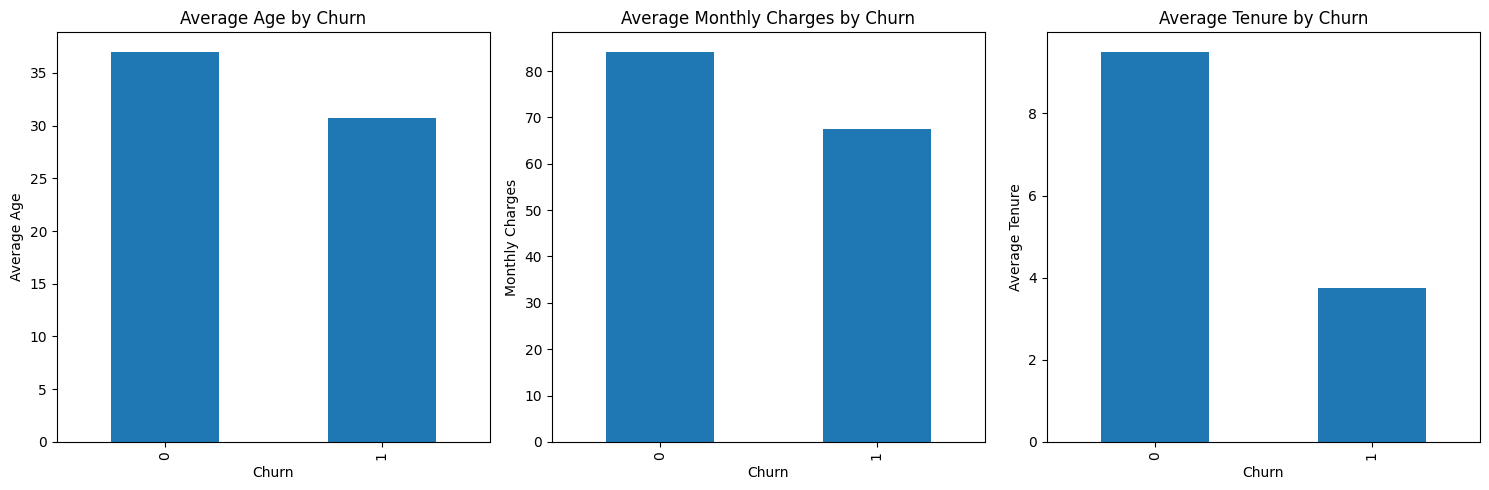

In [ ]:
# Overall Customer Data Visualization

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Age
df.groupby("Churn")["Age"].mean().plot(kind="bar", ax=axes[0])
axes[0].set_title("Average Age by Churn")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Average Age")

# Monthly Charges
df.groupby("Churn")["MonthlyCharges"].mean().plot(kind="bar", ax=axes[1])
axes[1].set_title("Average Monthly Charges by Churn")
axes[1].set_xlabel("Churn")
axes[1].set_ylabel("Monthly Charges")

# Tenure
df.groupby("Churn")["Tenure"].mean().plot(kind="bar", ax=axes[2])
axes[2].set_title("Average Tenure by Churn")
axes[2].set_xlabel("Churn")
axes[2].set_ylabel("Average Tenure")

plt.tight_layout()
plt.show()

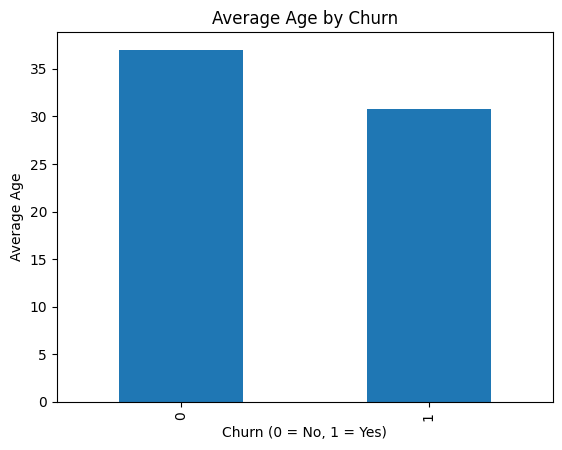

In [ ]:
# Age vs Churn visualization
df.groupby("Churn")["Age"].mean().plot(kind="bar")

plt.title("Average Age by Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Average Age")
plt.show()

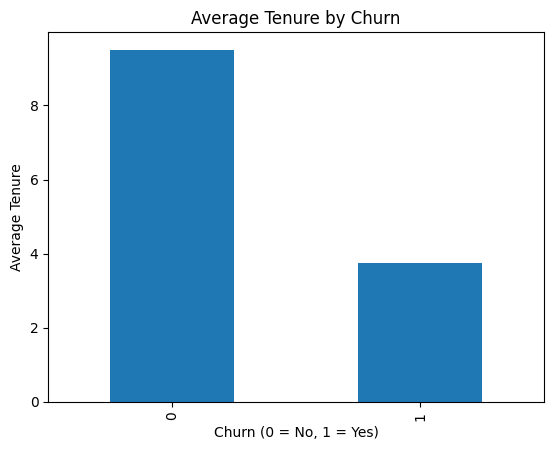

In [ ]:
# Tenure vs Churn visualization
df.groupby("Churn")["Tenure"].mean().plot(kind="bar")

plt.title("Average Tenure by Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Average Tenure")
plt.show()